In [1]:
# Cell 1
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, datasets, models
from torchvision.models import swin_v2_t

from sklearn.metrics import (
    roc_auc_score, roc_curve, accuracy_score, f1_score,
    confusion_matrix, classification_report
)

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# Paths
LOCAL_INPUT_ROOT = "E:/Major Project/data2"                  
DATASET_FOLDER = "chest_xray"                
DATA_ROOT = os.path.join(LOCAL_INPUT_ROOT, DATASET_FOLDER)

# Assuming we are using the 'mixup' models from your previous scripts
RESNET_PATH = "E:/Major Project/e2/models/r_mixup.pth"
DENSENET_PATH = "E:/Major Project/e2/models/d_mixup.pth"
EFFNET_PATH = "E:/Major Project/e2/models/ef_nomixup.pth"
SWIN_PATH = "E:/Major Project/e2/models/swin_mixup.pth"

BATCH = 16
NUM_WORKERS = 4
SEED = 42

def set_seed(seed=42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

Device: cuda


In [2]:
# Cell 2
# We set standard size to 256 to satisfy Swin. CNNs will be interpolated down dynamically.
IMG_SIZE_SWIN = 256

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE_SWIN, IMG_SIZE_SWIN)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

val_dir   = os.path.join(DATA_ROOT, "val")
test_dir  = os.path.join(DATA_ROOT, "test")

val_ds   = datasets.ImageFolder(val_dir, transform=val_transform)
test_ds  = datasets.ImageFolder(test_dir, transform=val_transform)

# We will use the validation set to train the Stacking Meta-Learner and Calibrator
val_loader   = DataLoader(val_ds, batch_size=BATCH, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print("Validation set size (for Meta-training):", len(val_ds))
print("Test set size (for final Evaluation):", len(test_ds))

Validation set size (for Meta-training): 798
Test set size (for final Evaluation): 624


In [3]:
# Cell 3
def load_resnet():
    model = models.resnet50(pretrained=False)
    model.fc = nn.Linear(model.fc.in_features, 1)
    model.load_state_dict(torch.load(RESNET_PATH, map_location=DEVICE))
    return model.eval().to(DEVICE)

def load_densenet():
    model = models.densenet121(pretrained=False)
    model.classifier = nn.Linear(model.classifier.in_features, 1)
    model.load_state_dict(torch.load(DENSENET_PATH, map_location=DEVICE))
    return model.eval().to(DEVICE)

def load_effnet():
    model = models.efficientnet_b3(pretrained=False)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, 1)
    model.load_state_dict(torch.load(EFFNET_PATH, map_location=DEVICE))
    return model.eval().to(DEVICE)

def load_swin():
    model = swin_v2_t(weights=None)
    model.head = nn.Linear(model.head.in_features, 1)
    model.load_state_dict(torch.load(SWIN_PATH, map_location=DEVICE))
    return model.eval().to(DEVICE)

print("Loading base models...")
model_resnet = load_resnet()
model_densenet = load_densenet()
model_effnet = load_effnet()
model_swin = load_swin()
print("All base models loaded successfully and set to eval mode.")

Loading base models...


e:\Major Project\env1\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
e:\Major Project\env1\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


All base models loaded successfully and set to eval mode.


In [4]:
# Cell 4
class WeightedStackingEnsemble(nn.Module):
    def __init__(self, resnet, densenet, effnet, swin):
        super().__init__()
        self.resnet = resnet
        self.densenet = densenet
        self.effnet = effnet
        self.swin = swin
        
        # Freeze all base models explicitly
        for model in [self.resnet, self.densenet, self.effnet, self.swin]:
            for param in model.parameters():
                param.requires_grad = False
                
        # Meta-learner: Maps 4 logits to 1 final logit
        self.meta_learner = nn.Linear(4, 1)
        
        # Initialize weights evenly
        nn.init.constant_(self.meta_learner.weight, 0.25)
        nn.init.constant_(self.meta_learner.bias, 0.0)

    def forward(self, x):
        # x is 256x256 (Optimal for Swin)
        
        # Dynamically interpolate for CNNs
        x_224 = F.interpolate(x, size=(224, 224), mode='bilinear', align_corners=False)
        
        with torch.no_grad():
            logit_res = self.resnet(x_224)
            logit_den = self.densenet(x_224)
            logit_eff = self.effnet(x_224)
            logit_swin = self.swin(x)
            
        # Concatenate features along feature dimension
        stacked_logits = torch.cat([logit_res, logit_den, logit_eff, logit_swin], dim=1)
        
        # Final combined logit
        final_logit = self.meta_learner(stacked_logits)
        
        return final_logit, stacked_logits # Return stacked for calibration later

ensemble_model = WeightedStackingEnsemble(model_resnet, model_densenet, model_effnet, model_swin).to(DEVICE)

In [5]:
# Cell 5
# 1. Train the Meta-Learner on the Validation Set
optimizer_stack = optim.Adam(ensemble_model.meta_learner.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.BCEWithLogitsLoss()

EPOCHS_META = 10
ensemble_model.train() # Only meta_learner requires grad

print("--- Training Stacking Meta-Learner on Val Set ---")
for epoch in range(EPOCHS_META):
    running_loss = 0.0
    for imgs, labels in val_loader:
        imgs = imgs.to(DEVICE)
        labels = labels.float().unsqueeze(1).to(DEVICE)
        
        optimizer_stack.zero_grad()
        final_logits, _ = ensemble_model(imgs)
        loss = criterion(final_logits, labels)
        
        loss.backward()
        optimizer_stack.step()
        running_loss += loss.item() * imgs.size(0)
        
    print(f"Epoch {epoch+1}/{EPOCHS_META} - Meta-Loss: {running_loss/len(val_ds):.4f}")

print("Learned Ensemble Weights:", ensemble_model.meta_learner.weight.data.cpu().numpy())

# 2. Evaluate Stacker on Test Set
def evaluate_ensemble(model, loader, device, return_base_logits=False):
    model.eval()
    all_final_logits, all_labels = [], []
    all_stacked_logits = []
    
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Evaluating"):
            imgs = imgs.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            
            final_logits, stacked_logits = model(imgs)
            
            all_final_logits.extend(final_logits.cpu().numpy().flatten())
            all_labels.extend(labels.cpu().numpy().flatten())
            if return_base_logits:
                all_stacked_logits.append(stacked_logits.cpu().numpy())

    y_true = np.array(all_labels)
    y_probs = 1 / (1 + np.exp(-np.array(all_final_logits))) # Sigmoid
    
    auc = roc_auc_score(y_true, y_probs)
    
    # Find best F1
    best_thr, best_f1 = 0.5, 0.0
    for thr in np.linspace(0.1, 0.9, 81):
        preds = (y_probs >= thr).astype(int)
        f1 = f1_score(y_true, preds)
        if f1 > best_f1:
            best_f1 = f1; best_thr = thr
            
    acc = accuracy_score(y_true, (y_probs >= best_thr).astype(int))
    
    results = {"auc": auc, "acc": acc, "f1": best_f1, "thr": best_thr, "y_probs": y_probs, "y_true": y_true}
    if return_base_logits:
        results["stacked"] = np.vstack(all_stacked_logits)
        
    return results

print("\n--- Evaluating Stacked Ensemble on Test Set ---")
stack_results = evaluate_ensemble(ensemble_model, test_loader, DEVICE, return_base_logits=True)

print(f"Stacked Ensemble -> AUC: {stack_results['auc']:.4f} | Acc: {stack_results['acc']:.4f} | Best F1: {stack_results['f1']:.4f} (Thr: {stack_results['thr']:.3f})")

y_pred_stack = (stack_results['y_probs'] >= stack_results['thr']).astype(int)
print("\nClassification Report (Stacked):\n", classification_report(stack_results['y_true'], y_pred_stack, digits=4))

--- Training Stacking Meta-Learner on Val Set ---
Epoch 1/10 - Meta-Loss: 0.1063
Epoch 2/10 - Meta-Loss: 0.1025
Epoch 3/10 - Meta-Loss: 0.0957
Epoch 4/10 - Meta-Loss: 0.1056
Epoch 5/10 - Meta-Loss: 0.0883
Epoch 6/10 - Meta-Loss: 0.0953
Epoch 7/10 - Meta-Loss: 0.0842
Epoch 8/10 - Meta-Loss: 0.0943
Epoch 9/10 - Meta-Loss: 0.0933
Epoch 10/10 - Meta-Loss: 0.1002
Learned Ensemble Weights: [[0.25581896 0.33233964 0.3991843  0.3784642 ]]

--- Evaluating Stacked Ensemble on Test Set ---


Evaluating: 100%|██████████| 39/39 [00:37<00:00,  1.05it/s]


Stacked Ensemble -> AUC: 0.9796 | Acc: 0.9455 | Best F1: 0.9574 (Thr: 0.800)

Classification Report (Stacked):
               precision    recall  f1-score   support

         0.0     0.9630    0.8889    0.9244       234
         1.0     0.9363    0.9795    0.9574       390

    accuracy                         0.9455       624
   macro avg     0.9496    0.9342    0.9409       624
weighted avg     0.9463    0.9455    0.9450       624



In [6]:
# Cell 6
class DynamicCalibrator(nn.Module):
    def __init__(self):
        super().__init__()
        # Input to this MLP is the variance of the 4 base model logits
        # Output is a temperature scalar T
        self.temp_net = nn.Sequential(
            nn.Linear(1, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Softplus() # Ensures temperature is strictly positive
        )
        
        # Initialize softly so initially T ≈ 1.0
        for m in self.temp_net.modules():
            if isinstance(m, nn.Linear):
                nn.init.uniform_(m.weight, -0.1, 0.1)
                nn.init.constant_(m.bias, 0.5)

    def forward(self, ensemble_logits, base_logits):
        # Calculate variance of base models along the feature axis
        variance = torch.var(base_logits, dim=1, keepdim=True)
        
        # Predict dynamic temperature based on variance
        temperature = self.temp_net(variance) + 1e-6 # prevent division by zero
        
        # Scale the ensemble logit
        calibrated_logits = ensemble_logits / temperature
        return calibrated_logits

calibrator = DynamicCalibrator().to(DEVICE)
optimizer_calib = optim.Adam(calibrator.parameters(), lr=1e-3, weight_decay=1e-4)

# 1. Train Calibrator on Validation set 
ensemble_model.eval() # Freeze stacker
calibrator.train()

print("--- Training Dynamic Calibrator on Val Set ---")
for epoch in range(EPOCHS_META):
    running_loss = 0.0
    for imgs, labels in val_loader:
        imgs = imgs.to(DEVICE)
        labels = labels.float().unsqueeze(1).to(DEVICE)
        
        with torch.no_grad():
            final_logits, stacked_logits = ensemble_model(imgs)
            
        optimizer_calib.zero_grad()
        
        calib_logits = calibrator(final_logits, stacked_logits)
        loss = criterion(calib_logits, labels)
        
        loss.backward()
        optimizer_calib.step()
        running_loss += loss.item() * imgs.size(0)
        
    print(f"Epoch {epoch+1}/{EPOCHS_META} - Calib-Loss: {running_loss/len(val_ds):.4f}")

--- Training Dynamic Calibrator on Val Set ---
Epoch 1/10 - Calib-Loss: 0.0677
Epoch 2/10 - Calib-Loss: 0.0675
Epoch 3/10 - Calib-Loss: 0.0675
Epoch 4/10 - Calib-Loss: 0.0674
Epoch 5/10 - Calib-Loss: 0.0675
Epoch 6/10 - Calib-Loss: 0.0674
Epoch 7/10 - Calib-Loss: 0.0672
Epoch 8/10 - Calib-Loss: 0.0672
Epoch 9/10 - Calib-Loss: 0.0672
Epoch 10/10 - Calib-Loss: 0.0671



--- Evaluating Calibrated Ensemble on Test Set ---


Evaluating Calibration: 100%|██████████| 39/39 [00:32<00:00,  1.20it/s]



==================== ABLATION STUDY RESULTS ====================
| Configuration                     |   Test AUC | Test Accuracy   |   Best F1 Score |   Optimal Threshold |
|:----------------------------------|-----------:|:----------------|----------------:|--------------------:|
| Weighted Stacking Ensemble        |     0.9796 | 94.55%          |          0.9574 |                0.8  |
| Stacking + Dynamic Scaling (DRSS) |     0.9796 | 94.55%          |          0.9574 |                0.81 |



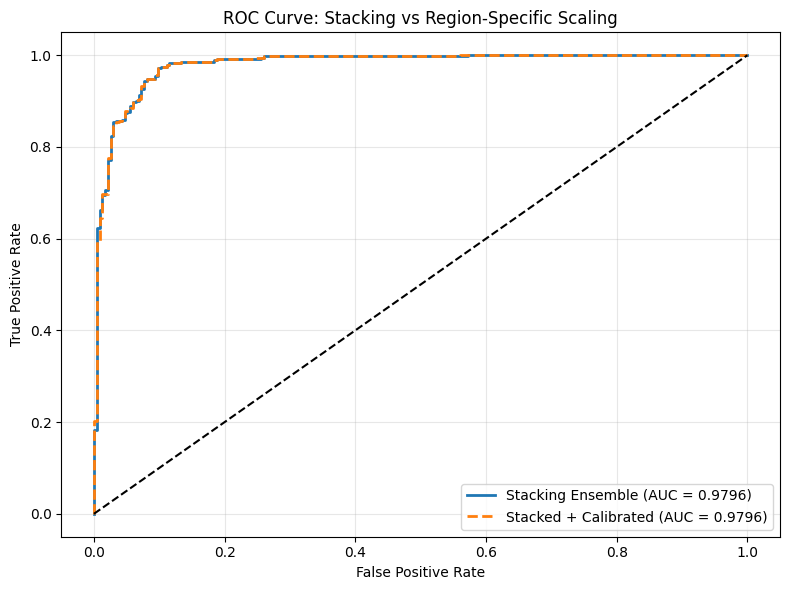

Classification Report (Stacked + Calibrated):
               precision    recall  f1-score   support

         0.0     0.9630    0.8889    0.9244       234
         1.0     0.9363    0.9795    0.9574       390

    accuracy                         0.9455       624
   macro avg     0.9496    0.9342    0.9409       624
weighted avg     0.9463    0.9455    0.9450       624



In [7]:
# Cell 7
def evaluate_calibrated(ensemble_model, calibrator, loader, device):
    ensemble_model.eval()
    calibrator.eval()
    
    all_calib_logits, all_labels = [], []
    
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Evaluating Calibration"):
            imgs = imgs.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            
            final_logits, stacked_logits = ensemble_model(imgs)
            calib_logits = calibrator(final_logits, stacked_logits)
            
            all_calib_logits.extend(calib_logits.cpu().numpy().flatten())
            all_labels.extend(labels.cpu().numpy().flatten())

    y_true = np.array(all_labels)
    y_probs = 1 / (1 + np.exp(-np.array(all_calib_logits)))
    
    auc = roc_auc_score(y_true, y_probs)
    
    best_thr, best_f1 = 0.5, 0.0
    for thr in np.linspace(0.1, 0.9, 81):
        preds = (y_probs >= thr).astype(int)
        f1 = f1_score(y_true, preds)
        if f1 > best_f1:
            best_f1 = f1; best_thr = thr
            
    acc = accuracy_score(y_true, (y_probs >= best_thr).astype(int))
    return auc, acc, best_f1, best_thr, y_probs, y_true

print("\n--- Evaluating Calibrated Ensemble on Test Set ---")
cal_auc, cal_acc, cal_f1, cal_thr, cal_probs, y_true = evaluate_calibrated(ensemble_model, calibrator, test_loader, DEVICE)

# Print Ablation Table
df_ablation = pd.DataFrame({
    "Configuration": ["Weighted Stacking Ensemble", "Stacking + Dynamic Scaling (DRSS)"],
    "Test AUC": [f"{stack_results['auc']:.4f}", f"{cal_auc:.4f}"],
    "Test Accuracy": [f"{stack_results['acc']*100:.2f}%", f"{cal_acc*100:.2f}%"],
    "Best F1 Score": [f"{stack_results['f1']:.4f}", f"{cal_f1:.4f}"],
    "Optimal Threshold": [f"{stack_results['thr']:.3f}", f"{cal_thr:.3f}"]
})

print("\n" + "="*20 + " ABLATION STUDY RESULTS " + "="*20)
print(df_ablation.to_markdown(index=False))
print("="*64 + "\n")

# Plot ROC comparison
fpr_stack, tpr_stack, _ = roc_curve(stack_results['y_true'], stack_results['y_probs'])
fpr_cal, tpr_cal, _ = roc_curve(y_true, cal_probs)

plt.figure(figsize=(8,6))
plt.plot(fpr_stack, tpr_stack, label=f"Stacking Ensemble (AUC = {stack_results['auc']:.4f})", linewidth=2)
plt.plot(fpr_cal, tpr_cal, label=f"Stacked + Calibrated (AUC = {cal_auc:.4f})", linestyle='--', linewidth=2)
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Stacking vs Region-Specific Scaling")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

y_pred_cal = (cal_probs >= cal_thr).astype(int)
print("Classification Report (Stacked + Calibrated):\n", classification_report(y_true, y_pred_cal, digits=4))

In [10]:
# Cell 8
import os
import torch

WORKING_DIR ="E:/Major Project/e2/ensemble_models/"
# Define save paths within your existing working directory
ENSEMBLE_SAVE_PATH = os.path.join(WORKING_DIR, "best_stacking_ensemble.pth")
CALIBRATOR_SAVE_PATH = os.path.join(WORKING_DIR, "best_dynamic_calibrator.pth")

# 1. Save the Stacking Ensemble Model
# This saves the frozen base models + the trained meta-learner weights
torch.save(ensemble_model.state_dict(), ENSEMBLE_SAVE_PATH)
print(f"Saved Stacking Ensemble to: {ENSEMBLE_SAVE_PATH}")

# 2. Save the Dynamic Calibrator Model
# This saves the MLP temperature scaling network
torch.save(calibrator.state_dict(), CALIBRATOR_SAVE_PATH)
print(f"Saved Dynamic Calibrator to: {CALIBRATOR_SAVE_PATH}")

Saved Stacking Ensemble to: E:/Major Project/e2/ensemble_models/best_stacking_ensemble.pth
Saved Dynamic Calibrator to: E:/Major Project/e2/ensemble_models/best_dynamic_calibrator.pth
